In [39]:
import numpy as np
import tensorflow as np

In [40]:
pairs = [
    ("thank you", "thanks"),
    ("take care", "stay safe"),
    ("good morning", "morning"),
    ("good night", "sleep well"),
    ("have a good day", "enjoy your day"),
    ("see you soon", "catch you later"),
    ("you are welcome", "no worries"),
    ("hope everything is fine", "hope all is well"),
    ("how are you", "how is it going"),
    ("I am fine", "I am good"),
    ("I am good", "doing well"),
    ("doing well", "great so far"),
    ("nice to meet you", "pleasure meeting you"),
    ("pleasure meeting you", "great to connect"),
    ("great to connect", "glad we met"),
    ("see you later", "catch you soon"),
    ("catch you soon", "talk soon"),
    ("talk soon", "until next time"),
    ("have fun", "enjoy yourself"),
    ("enjoy yourself", "have a blast"),
    ("have a blast", "make the most of it"),
    ("I appreciate it", "means a lot"),
    ("means a lot", "really grateful"),
    ("really grateful", "thanks for everything"),
    ("good to see you", "lovely seeing you"),
    ("lovely seeing you", "always nice catching up"),
    ("always nice catching up", "good vibes as always"),
    ("stay safe", "be careful"),
    ("be careful", "look after yourself"),
    ("look after yourself", "sending good wishes"),
    ("have a great evening", "enjoy your evening"),
    ("enjoy your evening", "relax and unwind"),
    ("relax and unwind", "have a peaceful night"),
    ("have a peaceful night", "rest well"),
    ("rest well", "sleep tight"),
    ("sleep tight", "good night"),
    ("good luck", "all the best"),
    ("all the best", "you got this"),
    ("you got this", "rooting for you"),
    ("rooting for you", "wishing success"),
    ("wishing success", "hope it works out great"),
    ("hope it works out great", "fingers crossed"),
    ("fingers crossed", "hope for the best"),
    ("sorry about that", "my bad"),
    ("my bad", "did not mean that"),
    ("did not mean that", "sorry if it sounded wrong"),
    ("no problem", "all good"),
    ("all good", "happens sometimes"),
    ("happens sometimes", "do not worry"),
    ("do not worry", "take it easy"),
    ("take it easy", "one thing at a time"),
    ("one thing at a time", "step by step"),
    ("step by step", "slow but steady"),
    ("slow but steady", "stay consistent"),
    ("I am tired", "need some rest"),
    ("need some rest", "time to recharge"),
    ("time to recharge", "back soon"),
    ("back soon", "see you later"),
    ("what are you doing", "what is going on"),
    ("what is going on", "any updates"),
    ("any updates", "what is the plan"),
    ("what is the plan", "next steps"),
    ("next steps", "moving forward"),
    ("moving forward", "one step ahead"),
    ("one step ahead", "progress matters"),
    ("progress matters", "keep going"),
    ("keep going", "stay consistent"),
    ("stay consistent", "you will get better"),
    ("sounds good", "nice plan"),
    ("nice plan", "great idea"),
    ("great idea", "love that"),
    ("love that", "so cool"),
    ("so cool", "nice to hear"),
    ("nice to hear", "happy for you"),
    ("happy for you", "glad to know"),
    ("let me check", "give me a moment"),
    ("give me a moment", "one sec"),
    ("one sec", "hold on"),
    ("hold on", "checking now"),
    ("checking now", "got it"),
    ("got it", "done"),
    ("done", "finished"),
    ("finished", "complete"),
    ("complete", "all set"),
    ("all set", "moving on"),
    ("moving on", "next"),
    ("next", "progress continues"),
    ("progress continues", "keep learning"),
    ("keep learning", "keep improving"),
    ("keep improving", "slow progress is still progress"),
    ("slow progress is still progress", "consistency beats rush"),
    ("consistency beats rush", "tomorrow is another chance"),
    ("tomorrow is another chance", "fresh start")
]

In [41]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts([a for a,b in pairs] + [b for a,b in pairs])
vocab_size = len(tokenizer.word_index) + 1 # Adding +1 for padding

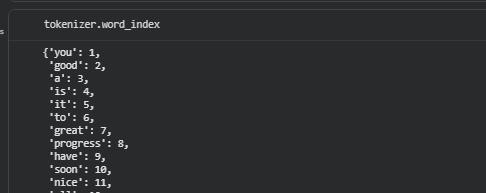

In [42]:
X, y = [], []
for a,b in pairs:
  X.append(tokenizer.texts_to_sequences([a])[0])
  y.append(tokenizer.texts_to_sequences([b])[0])

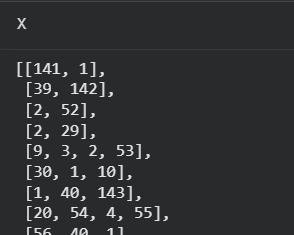

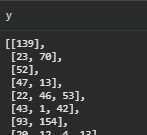

In [43]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_x = max(len(x) for x in X)
max_y = max(len(Y) for Y in y)
max_len = max(max_x, max_y)

X = pad_sequences(X, maxlen=max_len)
y = pad_sequences(y, maxlen=max_len)

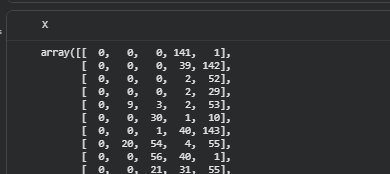

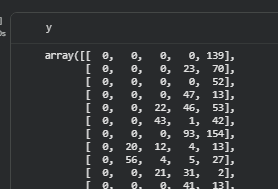

In [44]:
y = np.expand_dims(y, -1)

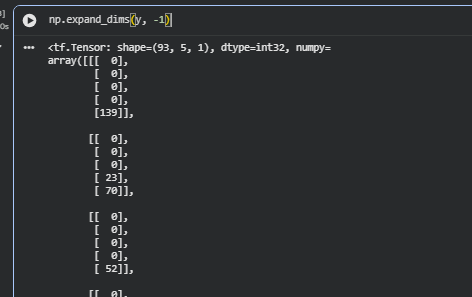

In [45]:
from tensorflow.keras import Model, layers, Sequential
class Seq2Seq(Model):
  def __init__(self, latent_dim):
    super().__init__()
    self.encoder = Sequential([
        layers.Embedding(vocab_size, 16),
        layers.LSTM(latent_dim)
    ])

    self.decoder = Sequential([
        layers.RepeatVector(max_len),
        layers.LSTM(latent_dim, return_sequences=True),
        layers.Dense(vocab_size, activation='softmax')
    ])

  def call(self, x):
    encoder_output = self.encoder(x)
    decoder_ouput = self.decoder(encoder_output)
    return decoder_ouput

In [55]:
model = Seq2Seq(latent_dim=64)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
model.fit(X, y, epochs=750, verbose=0)

In [56]:
def paraphrase(text):
  seq = tokenizer.texts_to_sequences([text])[0]
  seq = pad_sequences([seq], maxlen=max_len)
  pred = model.predict(seq)
  pred_seq = np.argmax(pred, axis=2)[0]
  words = [w for w,i in tokenizer.word_index.items() if i in pred_seq]
  return " ".join(word for word in words)

In [52]:
paraphrase("thank you")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


'thanks'

In [53]:
paraphrase("see you later")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


'you later catch'

In [54]:
paraphrase("I am tired")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


'rest need some'